In [3]:
import torch

In [4]:
inputs = torch.tensor(
    [[0.72, 0.45, 0.31], # Dream  (x^1)
     [0.75, 0.20, 0.55], # big    (x^2)
     [0.30, 0.80, 0.40], # and    (x^3)
     [0.85, 0.35, 0.60], # work   (x^4)
     [0.55, 0.15, 0.75], # for    (x^5)
     [0.25, 0.20, 0.85]] # it     (x^6)
)

# correspinding words
words = ['Dream', 'big', 'and', 'work', 'for', 'it']

Magnitude of vectors

In [5]:
magnitudes = torch.norm(inputs, dim=1)

print("Magnitudes of the input vectors:")
for word, magnitude in zip(words, magnitudes):
    print(f"{word}: {magnitude.item():.4f}")


Magnitudes of the input vectors:
Dream: 0.9039
big: 0.9513
and: 0.9434
work: 1.0977
for: 0.9421
it: 0.9083


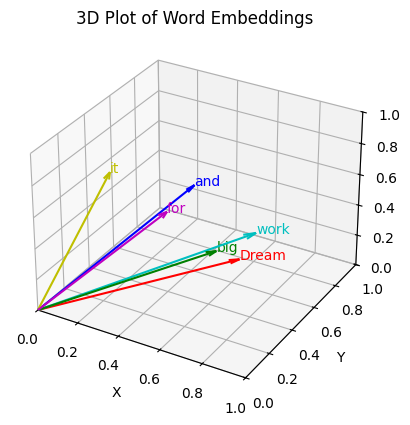

In [6]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Extract the x, y, z coordinates from the inputs
x_coords = inputs[:, 0].numpy()
y_coords = inputs[:, 1].numpy()
z_coords = inputs[:, 2].numpy()

# 3D plot with vectors from origin
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

colors = ['r', 'g', 'b', 'c', 'm', 'y']  # Different colors for each vector

for (x, y, z, word, color) in zip(x_coords, y_coords, z_coords, words, colors):
    ax.quiver(0, 0, 0, x, y, z, color=color, arrow_length_ratio=0.05)
    ax.text(x, y, z, word, fontsize=10, color=color)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_zlim([0, 1])
ax.set_title('3D Plot of Word Embeddings')
plt.show()

Dot Product between 2nd input token and all words

In [7]:
query = inputs[1]  # big

attn_scores_2 = torch.empty(inputs.shape[0])  
for i,x_i in enumerate(inputs):
    attn_scores_2[i] = torch.dot(query, x_i) 

print(attn_scores_2)

tensor([0.8005, 0.9050, 0.6050, 1.0375, 0.8550, 0.6950])


Normalizing the attention weights

In [8]:
attn_weights_2_tmp = attn_scores_2 / torch.sum(attn_scores_2)

print("Attention weights:", attn_weights_2_tmp)
print("Sum:", attn_weights_2_tmp.sum())

Attention weights: tensor([0.1634, 0.1848, 0.1235, 0.2118, 0.1746, 0.1419])
Sum: tensor(1.0000)


Softmax normalization

In [9]:
import tensorflow as tf

attn_scores_2_tf = tf.convert_to_tensor(attn_scores_2.numpy())

attn_weights_2_tf = tf.nn.softmax(attn_scores_2_tf)

print("Attention weights (TensorFlow):", attn_weights_2_tf.numpy())
print("Sum (TensorFlow):", tf.reduce_sum(attn_weights_2_tf).numpy())


Attention weights (TensorFlow): [0.16244562 0.18033987 0.13359907 0.20589025 0.17154458 0.14618066]
Sum (TensorFlow): 1.0


In [12]:
attn_weights_2 = torch.softmax(attn_scores_2, dim=0)

print("Attention weights (PyTorch):", attn_weights_2)
print("Sum (PyTorch):", attn_weights_2.sum())

Attention weights (PyTorch): tensor([0.1624, 0.1803, 0.1336, 0.2059, 0.1715, 0.1462])
Sum (PyTorch): tensor(1.0000)


Attention Scores for all 

In [18]:
attn_scores = inputs @ inputs.T # multiplies each input vector with all other input vectors (including itself) to get the attention scores
print(attn_scores)

tensor([[0.8170, 0.8005, 0.7000, 0.9555, 0.6960, 0.5335],
        [0.8005, 0.9050, 0.6050, 1.0375, 0.8550, 0.6950],
        [0.7000, 0.6050, 0.8900, 0.7750, 0.5850, 0.5750],
        [0.9555, 1.0375, 0.7750, 1.2050, 0.9700, 0.7925],
        [0.6960, 0.8550, 0.5850, 0.9700, 0.8875, 0.8050],
        [0.5335, 0.6950, 0.5750, 0.7925, 0.8050, 0.8250]])


In [19]:
attn_weights = torch.softmax(attn_scores, dim=-1) # apply softmax along the last dimension to get attention weights
print("Attention weights:", attn_weights)

Attention weights: tensor([[0.1766, 0.1738, 0.1571, 0.2029, 0.1565, 0.1330],
        [0.1624, 0.1803, 0.1336, 0.2059, 0.1715, 0.1462],
        [0.1675, 0.1523, 0.2025, 0.1805, 0.1493, 0.1478],
        [0.1648, 0.1789, 0.1376, 0.2115, 0.1672, 0.1400],
        [0.1491, 0.1747, 0.1334, 0.1960, 0.1805, 0.1662],
        [0.1396, 0.1641, 0.1455, 0.1809, 0.1831, 0.1868]])


In [22]:
print("Sum of all the rows in the attention weights matrix:", attn_weights.sum(dim=-1)) # sum along the last dimension to get the sum of each row

Sum of all the rows in the attention weights matrix: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


Context Vectors

In [24]:
all_context_vecs = attn_weights @ inputs # multiply the attention weights with the input vectors to get the context vectors
print(all_context_vecs)

tensor([[0.5965, 0.3611, 0.5654],
        [0.5982, 0.3431, 0.5794],
        [0.5681, 0.3830, 0.5627],
        [0.6008, 0.3471, 0.5758],
        [0.5859, 0.3377, 0.5900],
        [0.5684, 0.3402, 0.5964]])


In [25]:
# Context vectors of big
context_vec_2 = all_context_vecs[1]
print("Context vector for 'big':", context_vec_2)

Context vector for 'big': tensor([0.5982, 0.3431, 0.5794])


Adding context vector for plotting

In [26]:
inputs = torch.cat((inputs, context_vec_2.unsqueeze(0)), dim=0) 

words.append('context_vector_big')

print("Updated inputs tensor:")
print(inputs)

print("\nUpdated words list:")
print(words)

Updated inputs tensor:
tensor([[0.7200, 0.4500, 0.3100],
        [0.7500, 0.2000, 0.5500],
        [0.3000, 0.8000, 0.4000],
        [0.8500, 0.3500, 0.6000],
        [0.5500, 0.1500, 0.7500],
        [0.2500, 0.2000, 0.8500],
        [0.5982, 0.3431, 0.5794]])

Updated words list:
['Dream', 'big', 'and', 'work', 'for', 'it', 'context_vector_big']


Plotting Context vector of big

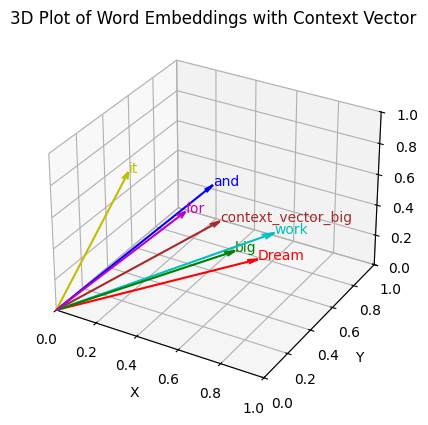

In [28]:
x_coords = inputs[:, 0].numpy()
y_coords = inputs[:, 1].numpy()
z_coords = inputs[:, 2].numpy()

# 3D plot with vectors from origin
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

colors = ['r', 'g', 'b', 'c', 'm', 'y', 'brown']  # Different colors for each vector

for (x, y, z, word, color) in zip(x_coords, y_coords, z_coords, words, colors):
    ax.quiver(0, 0, 0, x, y, z, color=color, arrow_length_ratio=0.05)
    ax.text(x, y, z, word, fontsize=10, color=color)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_zlim([0, 1])
ax.set_title('3D Plot of Word Embeddings with Context Vector')
plt.show()

Before and After transformation

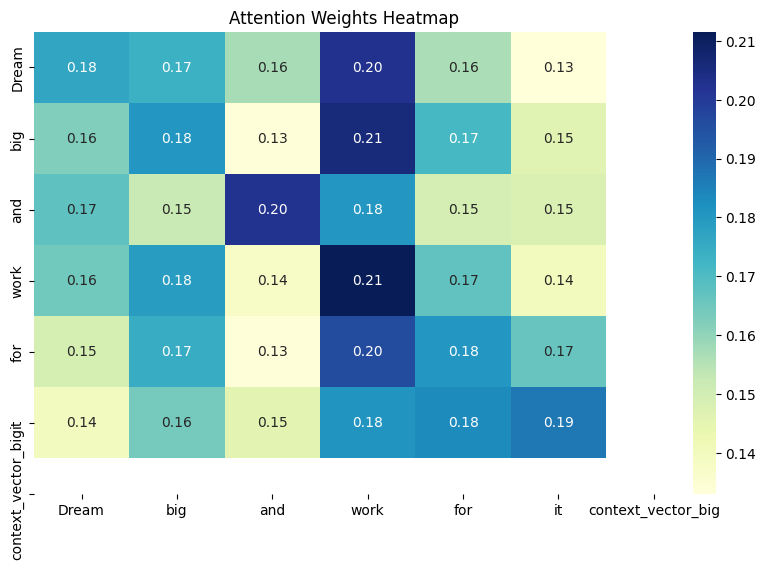

In [29]:
# Now, let's visualize the attention weights for each word in a heatmap.
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(attn_weights.detach().numpy(), annot=True, fmt=".2f", xticklabels=words, yticklabels=words, cmap="YlGnBu")
plt.title("Attention Weights Heatmap")
plt.show()